In [138]:
import random
import matplotlib.pyplot as plt

courses = [
    ("AI", "DosenA"),
    ("ML", "DosenB"),
    ("DB", "DosenC"),
    ("CN", "DosenD"),
    ("SE", "DosenE"),
    ("OS", "DosenF"),
    ("IR", "DosenA"),
    ("NLP", "DosenB"),
    ("CV", "DosenC"),
    ("IOT", "DosenD"),
    ("HCI", "DosenE"),
    ("CyberSec", "DosenF"),
    ("BigData", "DosenA"),
    ("DL", "DosenB"),
    ("NoSQL", "DosenC"),
    ("Cloud", "DosenD"),
    ("UX", "DosenE"),
    ("SecEng", "DosenF"),
    ("Agile", "DosenA"),
    ("RL", "DosenB"),
    ("ETL", "DosenC"),
    ("DevOps", "DosenD"),
    ("GameDev", "DosenE"),
    ("Blockchain", "DosenF")
]

rooms = ["R1", "R2", "R3", "R4"]

timeslots = [
    "Senin-08", "Senin-10", "Senin-13",
    "Selasa-08", "Selasa-10", "Selasa-13",
    "Rabu-08", "Rabu-10", "Rabu-13",
    "Kamis-08", "Kamis-10", "Kamis-13"
]

print("Jumlah Mata Kuliah :", len(courses))
print("Jumlah Ruangan :", len(rooms))
print("Jumlah Slot :", len(timeslots))

Jumlah Mata Kuliah : 24
Jumlah Ruangan : 4
Jumlah Slot : 12


In [139]:
# Membuat satu individu (satu jadwal lengkap)

def create_individual():
    individual = []

    for course in courses:
        room = random.choice(rooms)
        slot = random.choice(timeslots)

        individual.append({
            "course": course[0],
            "lecturer": course[1],
            "room": room,
            "timeslot": slot
        })

    return individual

In [140]:
POPULATION_SIZE = 60

population = []

for i in range(POPULATION_SIZE):
    population.append(create_individual())

print("Jumlah Individu :", len(population))

Jumlah Individu : 60


In [141]:
print("Individu Pertama\n")

for gene in population[0]:
    print(gene)

Individu Pertama

{'course': 'AI', 'lecturer': 'DosenA', 'room': 'R2', 'timeslot': 'Rabu-08'}
{'course': 'ML', 'lecturer': 'DosenB', 'room': 'R1', 'timeslot': 'Kamis-13'}
{'course': 'DB', 'lecturer': 'DosenC', 'room': 'R4', 'timeslot': 'Senin-10'}
{'course': 'CN', 'lecturer': 'DosenD', 'room': 'R1', 'timeslot': 'Rabu-08'}
{'course': 'SE', 'lecturer': 'DosenE', 'room': 'R1', 'timeslot': 'Rabu-13'}
{'course': 'OS', 'lecturer': 'DosenF', 'room': 'R3', 'timeslot': 'Senin-13'}
{'course': 'IR', 'lecturer': 'DosenA', 'room': 'R2', 'timeslot': 'Rabu-08'}
{'course': 'NLP', 'lecturer': 'DosenB', 'room': 'R3', 'timeslot': 'Rabu-13'}
{'course': 'CV', 'lecturer': 'DosenC', 'room': 'R4', 'timeslot': 'Selasa-08'}
{'course': 'IOT', 'lecturer': 'DosenD', 'room': 'R1', 'timeslot': 'Selasa-08'}
{'course': 'HCI', 'lecturer': 'DosenE', 'room': 'R4', 'timeslot': 'Rabu-08'}
{'course': 'CyberSec', 'lecturer': 'DosenF', 'room': 'R3', 'timeslot': 'Selasa-08'}
{'course': 'BigData', 'lecturer': 'DosenA', 'room': 

In [142]:
def calculate_fitness(individual):

    conflict = 0

    # -------------------------------
    # Konflik Ruang dan Waktu
    # -------------------------------

    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):

            if (
                individual[i]["room"] == individual[j]["room"]
                and
                individual[i]["timeslot"] == individual[j]["timeslot"]
            ):
                conflict += 1

    # -------------------------------
    # Konflik Dosen dan Waktu
    # -------------------------------

    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):

            if (
                individual[i]["lecturer"] == individual[j]["lecturer"]
                and
                individual[i]["timeslot"] == individual[j]["timeslot"]
            ):
                conflict += 1

    # -------------------------------
    # Konflik Dosen Mengajar
    # Lebih dari Sekali dalam Sehari
    # -------------------------------

    for lecturer in set([x["lecturer"] for x in individual]):

        days = []

        for gene in individual:

            if gene["lecturer"] == lecturer:

                day = gene["timeslot"].split("-")[0]

                days.append(day)

        conflict += len(days) - len(set(days))

    fitness = max(0, 100 - conflict * 5)

    return fitness, conflict

In [143]:
fitness, conflict = calculate_fitness(population[0])

print("Fitness :", fitness)
print("Jumlah Konflik :", conflict)

Fitness : 30
Jumlah Konflik : 14


In [144]:
fitness_scores = []

for individual in population:

    fitness, conflict = calculate_fitness(individual)

    fitness_scores.append(fitness)

print(fitness_scores)

[30, 10, 0, 20, 40, 45, 20, 20, 45, 15, 25, 0, 10, 30, 5, 30, 45, 5, 0, 30, 0, 0, 15, 15, 45, 0, 0, 50, 5, 10, 0, 0, 25, 0, 0, 10, 10, 10, 20, 10, 35, 35, 25, 30, 0, 10, 15, 35, 5, 55, 0, 35, 40, 15, 20, 30, 35, 15, 40, 0]


In [145]:
best_index = fitness_scores.index(max(fitness_scores))

best_individual = population[best_index]

best_fitness, best_conflict = calculate_fitness(best_individual)

print("Fitness Terbaik :", best_fitness)
print("Jumlah Konflik :", best_conflict)

Fitness Terbaik : 55
Jumlah Konflik : 9


In [146]:
def tournament_selection(population):

    tournament_size = 5

    candidates = random.sample(population, tournament_size)

    best = candidates[0]
    best_fitness, _ = calculate_fitness(best)

    for individual in candidates:

        fitness, _ = calculate_fitness(individual)

        if fitness > best_fitness:
            best = individual
            best_fitness = fitness

    return best

In [147]:
parent1 = tournament_selection(population)

fitness, conflict = calculate_fitness(parent1)

print("Fitness Parent :", fitness)
print("Konflik :", conflict)

Fitness Parent : 55
Konflik : 9


In [148]:
CROSSOVER_RATE = 0.85

def crossover(parent1, parent2):

    if random.random() > CROSSOVER_RATE:
        return parent1.copy(), parent2.copy()

    point = random.randint(1, len(parent1)-2)

    child1 = parent1[:point] + parent2[point:]

    child2 = parent2[:point] + parent1[point:]

    return child1, child2

In [149]:
parent1 = tournament_selection(population)

parent2 = tournament_selection(population)

child1, child2 = crossover(parent1, parent2)

print("Child 1 :", len(child1))
print("Child 2 :", len(child2))

Child 1 : 24
Child 2 : 24


In [150]:
MUTATION_RATE = 0.20

def mutate(individual):

    for gene in individual:

        if random.random() < MUTATION_RATE:

            gene["room"] = random.choice(rooms)

            gene["timeslot"] = random.choice(timeslots)

    return individual

In [151]:
child1 = mutate(child1)

print(child1[0])

{'course': 'AI', 'lecturer': 'DosenA', 'room': 'R2', 'timeslot': 'Senin-10'}


In [152]:
MAX_GENERATIONS = 100

best_history = []
avg_history = []

for generation in range(MAX_GENERATIONS):

    new_population = []

    while len(new_population) < POPULATION_SIZE:

        parent1 = tournament_selection(population)
        parent2 = tournament_selection(population)

        child1, child2 = crossover(parent1, parent2)

        child1 = mutate(child1)
        child2 = mutate(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)

    population = new_population

    fitness_scores = []

    for individual in population:

        fitness, conflict = calculate_fitness(individual)

        fitness_scores.append(fitness)

    best_history.append(max(fitness_scores))
    avg_history.append(sum(fitness_scores)/len(fitness_scores))

    print(f"Generasi {generation+1} | Fitness Terbaik = {max(fitness_scores)} | Fitness Rata-rata = {sum(fitness_scores)/len(fitness_scores):.2f}")

Generasi 1 | Fitness Terbaik = 50 | Fitness Rata-rata = 22.75
Generasi 2 | Fitness Terbaik = 50 | Fitness Rata-rata = 21.25
Generasi 3 | Fitness Terbaik = 50 | Fitness Rata-rata = 19.50
Generasi 4 | Fitness Terbaik = 55 | Fitness Rata-rata = 19.58
Generasi 5 | Fitness Terbaik = 55 | Fitness Rata-rata = 23.50
Generasi 6 | Fitness Terbaik = 55 | Fitness Rata-rata = 17.00
Generasi 7 | Fitness Terbaik = 65 | Fitness Rata-rata = 23.75
Generasi 8 | Fitness Terbaik = 45 | Fitness Rata-rata = 19.25
Generasi 9 | Fitness Terbaik = 60 | Fitness Rata-rata = 22.17
Generasi 10 | Fitness Terbaik = 60 | Fitness Rata-rata = 25.00
Generasi 11 | Fitness Terbaik = 55 | Fitness Rata-rata = 19.17
Generasi 12 | Fitness Terbaik = 45 | Fitness Rata-rata = 14.58
Generasi 13 | Fitness Terbaik = 55 | Fitness Rata-rata = 16.25
Generasi 14 | Fitness Terbaik = 45 | Fitness Rata-rata = 11.17
Generasi 15 | Fitness Terbaik = 50 | Fitness Rata-rata = 18.42
Generasi 16 | Fitness Terbaik = 65 | Fitness Rata-rata = 25.92
G

In [153]:
best_index = fitness_scores.index(max(fitness_scores))

best_schedule = population[best_index]

fitness, conflict = calculate_fitness(best_schedule)

print("="*60)
print("JADWAL TERBAIK")
print("="*60)

for i, gene in enumerate(best_schedule, start=1):

    print(f"{i}. {gene['course']:12} | {gene['lecturer']:8} | {gene['room']} | {gene['timeslot']}")

print("="*60)
print("Fitness Terbaik :", fitness)
print("Jumlah Konflik :", conflict)

JADWAL TERBAIK
1. AI           | DosenA   | R1 | Rabu-13
2. ML           | DosenB   | R4 | Rabu-10
3. DB           | DosenC   | R1 | Kamis-13
4. CN           | DosenD   | R3 | Senin-10
5. SE           | DosenE   | R3 | Kamis-08
6. OS           | DosenF   | R1 | Senin-08
7. IR           | DosenA   | R3 | Kamis-08
8. NLP          | DosenB   | R4 | Kamis-13
9. CV           | DosenC   | R3 | Kamis-10
10. IOT          | DosenD   | R2 | Selasa-08
11. HCI          | DosenE   | R2 | Rabu-08
12. CyberSec     | DosenF   | R4 | Senin-10
13. BigData      | DosenA   | R4 | Senin-13
14. DL           | DosenB   | R1 | Senin-10
15. NoSQL        | DosenC   | R2 | Kamis-08
16. Cloud        | DosenD   | R4 | Rabu-13
17. UX           | DosenE   | R3 | Kamis-13
18. SecEng       | DosenF   | R1 | Kamis-13
19. Agile        | DosenA   | R2 | Selasa-08
20. RL           | DosenB   | R2 | Senin-10
21. ETL          | DosenC   | R4 | Rabu-08
22. DevOps       | DosenD   | R1 | Rabu-08
23. GameDev      | DosenE   | 

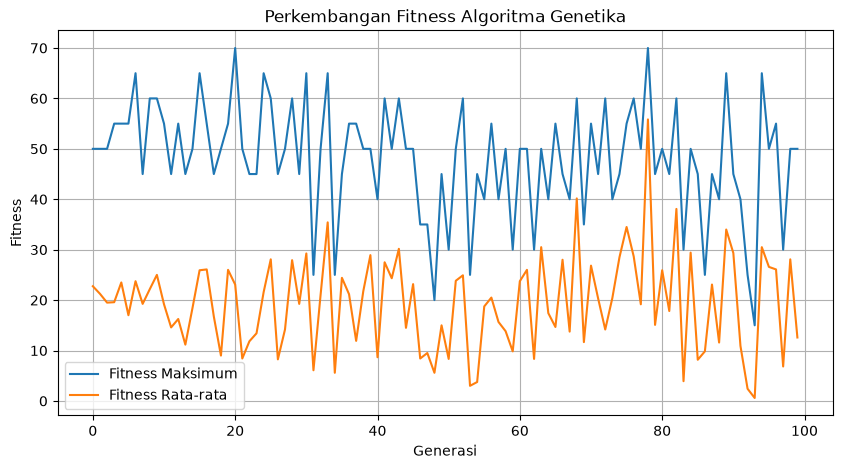

In [154]:
plt.figure(figsize=(10,5))

plt.plot(best_history, label="Fitness Maksimum")

plt.plot(avg_history, label="Fitness Rata-rata")

plt.title("Perkembangan Fitness Algoritma Genetika")

plt.xlabel("Generasi")

plt.ylabel("Fitness")

plt.grid(True)

plt.legend()

plt.show()